# Car Price Prediction - Exploratory Data Analysis
## Data Cleaning and Visualization

**Purpose**: Explore and understand the dataset through visualizations and statistics.

**Workflow**:
1. Data Loading & Exploration
2. Data Cleaning
3. Exploratory Data Analysis (EDA)

**Note**: For model training, use `train_xgboost_advanced.py`

---
## Setup & Imports

In [19]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Packages loaded successfully")

✓ Packages loaded successfully


---
## 1. Data Loading & Initial Exploration

In [20]:
# Load raw data
data = pd.read_csv('car_price_dataset.csv')

print(f"Dataset Shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Dataset Shape: (9788, 17)

First few rows:


,Unnamed: 0,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Date,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price
0,0,AUDI,A1,2016,990.0,Automatic,Petrol,99000.0,Gampaha,2025-02-05,No Leasing,USED,Available,Available,Available,Available,100.0
1,1,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2025-01-14,No Leasing,USED,Available,Available,Available,Available,97.0
2,2,AUDI,A1,2018,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,2025-01-23,No Leasing,USED,Available,Available,Available,Available,98.5
3,3,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Negombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,107.0
4,4,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,99.5


In [21]:
# Basic information
print("Dataset Info:")
print("="*60)
data.info()

print("\n" + "="*60)
print("Missing Values:")
print("="*60)
missing = data.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found!")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9788 entries, 0 to 9787
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9788 non-null   int64  
 1   Brand           9788 non-null   object 
 2   Model           9788 non-null   object 
 3   YOM             9788 non-null   int64  
 4   Engine (cc)     9788 non-null   float64
 5   Gear            9788 non-null   object 
 6   Fuel Type       9788 non-null   object 
 7   Millage(KM)     9788 non-null   float64
 8   Town            9788 non-null   object 
 9   Date            9788 non-null   object 
 10  Leasing         9788 non-null   object 
 11  Condition       9788 non-null   object 
 12  AIR CONDITION   9788 non-null   object 
 13  POWER STEERING  9788 non-null   object 
 14  POWER MIRROR    9788 non-null   object 
 15  POWER WINDOW    9788 non-null   object 
 16  Price           9788 non-null   float64
dtypes: float64(3), int6

In [22]:
# Statistical summary
print("Numerical Features Summary:")
data.describe()

Numerical Features Summary:


,Unnamed: 0,YOM,Engine (cc),Millage(KM),Price
count,9788.000000,9788.000000,9788.000000,9788.000000,9788.000000
mean,4893.758991,2006.759093,1260.442358,200649.979567,53.464275
std,2826.028988,9.831574,403.769059,108147.314860,43.625049
min,0.000000,1956.000000,573.000000,11000.000000,2.650000
25%,2446.750000,2001.000000,1000.000000,110000.000000,26.250000
50%,4893.500000,2009.000000,1300.000000,176000.000000,43.000000
75%,7341.250000,2015.000000,1500.000000,264000.000000,69.750000
max,9788.000000,2024.000000,4800.000000,759000.000000,790.000000


In [23]:
# Categorical features
print("Categorical Features:")
print("="*60)
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unique_count = data[col].nunique()
    print(f"\n{col}: {unique_count} unique values")
    if unique_count <= 10:
        print(f"  Values: {data[col].value_counts().to_dict()}")
    else:
        print(f"  Top 5: {data[col].value_counts().head().to_dict()}")

Categorical Features:

Brand: 50 unique values
  Top 5: {'TOYOTA': 3089, 'SUZUKI': 2473, 'NISSAN': 1248, 'HONDA': 681, 'MITSUBISHI': 284}

Model: 1555 unique values
  Top 5: {'ALTO': 392, 'VITZ': 366, 'WAGON R STINGRAY': 282, 'MARUTI': 229, 'WAGON R': 204}

Gear: 2 unique values
  Values: {'Automatic': 6305, 'Manual': 3483}

Fuel Type: 4 unique values
  Values: {'Petrol': 7866, 'Hybrid': 1239, 'Diesel': 614, 'Electric': 69}

Town: 107 unique values
  Top 5: {'Colombo': 1038, 'Gampaha': 657, 'Kurunegala': 646, 'Kandy': 637, 'Matara': 319}

Date: 65 unique values
  Top 5: {'2025-02-05': 645, '2025-02-04': 532, '2025-02-03': 457, '2025-02-01': 407, '2025-02-02': 391}

Leasing: 2 unique values
  Values: {'No Leasing': 9384, 'Ongoing Lease': 404}

Condition: 2 unique values
  Values: {'USED': 9694, 'NEW': 94}

AIR CONDITION: 2 unique values
  Values: {'Available': 9590, 'Not_Available': 198}

POWER STEERING: 2 unique values
  Values: {'Available': 8918, 'Not_Available': 870}

POWER MIRROR: 

---
## 2. Data Cleaning

In [24]:
# Drop unnecessary columns
data_clean = data.copy()

if 'Unnamed: 0' in data_clean.columns:
    data_clean = data_clean.drop(columns=['Unnamed: 0'])
    print("✓ Dropped 'Unnamed: 0' column")

print(f"\nCleaned dataset shape: {data_clean.shape}")

✓ Dropped 'Unnamed: 0' column

Cleaned dataset shape: (9788, 16)


In [25]:
# Calculate Car_Age from Date and YOM
if 'Date' in data_clean.columns and 'YOM' in data_clean.columns:
    data_clean['Date'] = pd.to_datetime(data_clean['Date'], errors='coerce')
    data_clean['Listing_Year'] = data_clean['Date'].dt.year
    data_clean['Car_Age'] = data_clean['Listing_Year'] - data_clean['YOM']
    
    # Handle negative ages
    negative_ages = (data_clean['Car_Age'] < 0).sum()
    if negative_ages > 0:
        print(f"⚠ Found {negative_ages} rows with negative age")
        data_clean = data_clean[data_clean['Car_Age'] >= 0]
    
    print(f"✓ Car_Age calculated")
    print(f"  Date range: {data_clean['Date'].min()} to {data_clean['Date'].max()}")
    print(f"  Car_Age range: {data_clean['Car_Age'].min()} to {data_clean['Car_Age'].max()} years")
    
    # Drop Date, Listing_Year, YOM
    data_clean = data_clean.drop(columns=['Date', 'Listing_Year', 'YOM'])

✓ Car_Age calculated
  Date range: 2024-12-03 00:00:00 to 2025-02-05 00:00:00
  Car_Age range: 0 to 69 years


In [26]:
# Check for duplicates
duplicates = data_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    data_clean = data_clean.drop_duplicates()
    print(f"✓ Duplicates removed")

Duplicate rows: 199
Removing 199 duplicate rows...
✓ Duplicates removed


In [27]:
# Check for outliers in Price
print("Price Distribution:")
print(f"  Min: {data_clean['Price'].min()}")
print(f"  Max: {data_clean['Price'].max()}")
print(f"  Mean: {data_clean['Price'].mean():.2f}")
print(f"  Median: {data_clean['Price'].median():.2f}")
print(f"  Std: {data_clean['Price'].std():.2f}")

# Remove extreme outliers (optional)
Q1 = data_clean['Price'].quantile(0.25)
Q3 = data_clean['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = ((data_clean['Price'] < lower_bound) | (data_clean['Price'] > upper_bound)).sum()
print(f"\nPrice outliers (3×IQR): {outliers}")

Price Distribution:
  Min: 2.65
  Max: 790.0
  Mean: 53.51
  Median: 43.00
  Std: 43.73

Price outliers (3×IQR): 132


---
## 3. Exploratory Data Analysis (EDA)

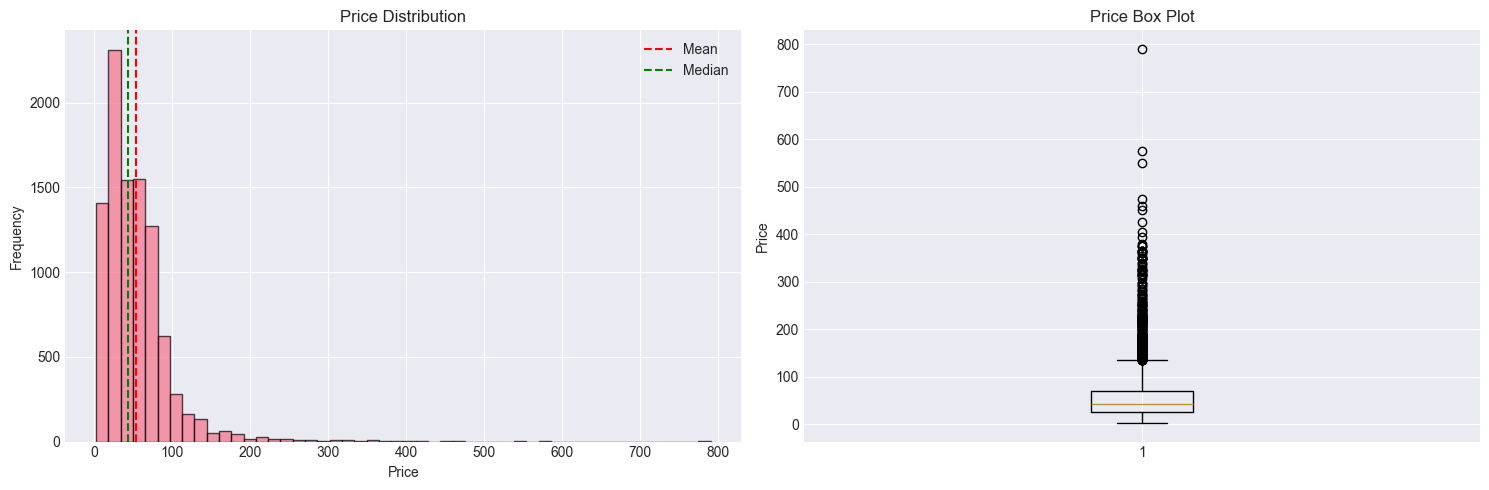

In [28]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(data_clean['Price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].axvline(data_clean['Price'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(data_clean['Price'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Box plot
axes[1].boxplot(data_clean['Price'])
axes[1].set_ylabel('Price')
axes[1].set_title('Price Box Plot')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

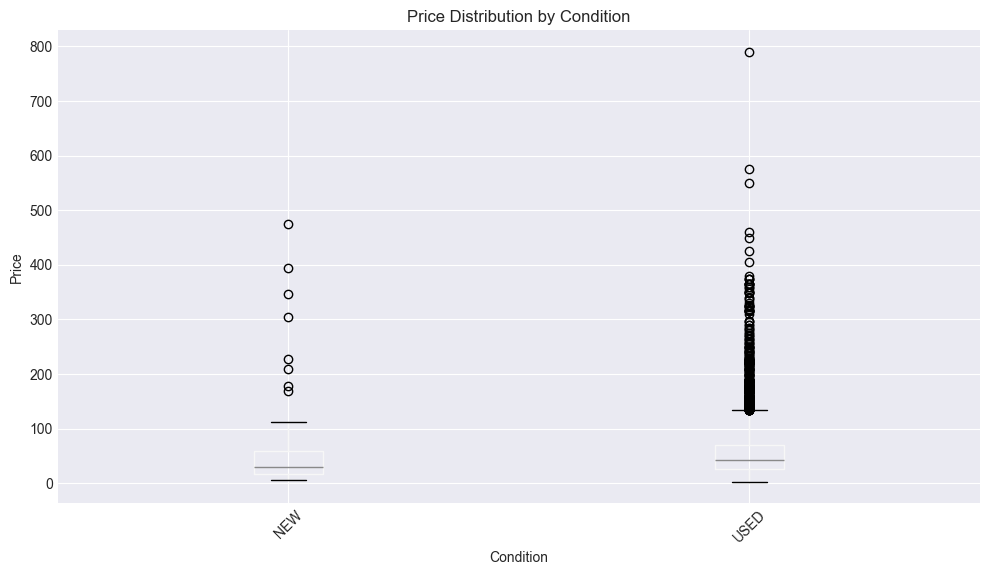


Mean Price by Condition:
Condition
NEW     56.686210
USED    53.475205
Name: Price, dtype: float64


In [29]:
# Price by Condition
plt.figure(figsize=(10, 6))
data_clean.boxplot(column='Price', by='Condition', figsize=(10, 6))
plt.suptitle('')
plt.title('Price Distribution by Condition')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMean Price by Condition:")
print(data_clean.groupby('Condition')['Price'].mean().sort_values(ascending=False))

<Figure size 1200x600 with 0 Axes>

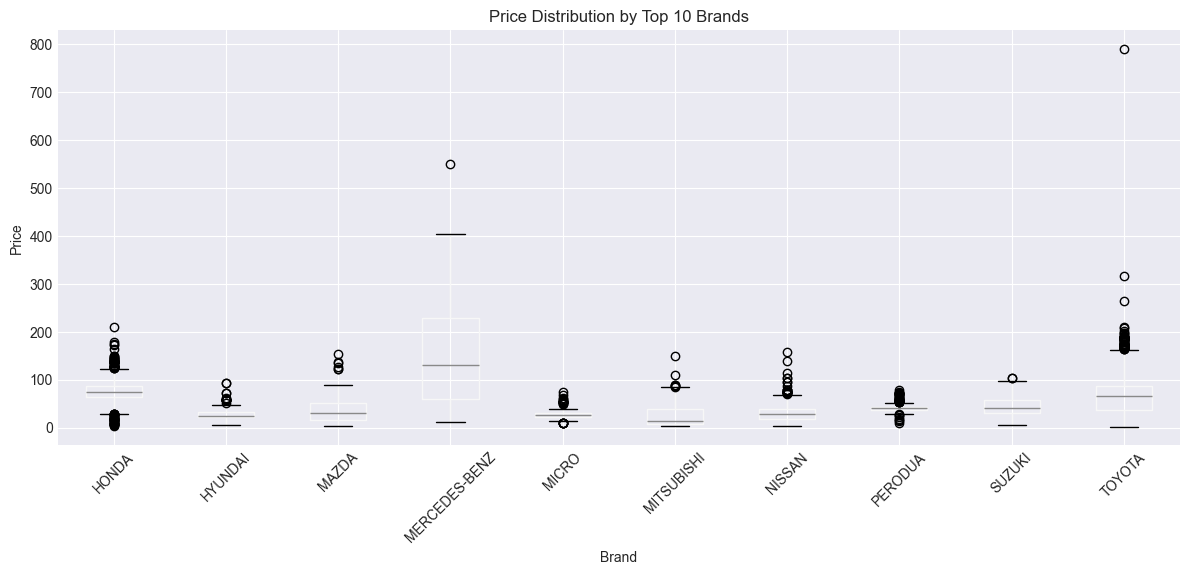

In [30]:
# Price by Top 10 Brands
top_brands = data_clean['Brand'].value_counts().head(10).index
data_top_brands = data_clean[data_clean['Brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
data_top_brands.boxplot(column='Price', by='Brand', figsize=(12, 6))
plt.suptitle('')
plt.title('Price Distribution by Top 10 Brands')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

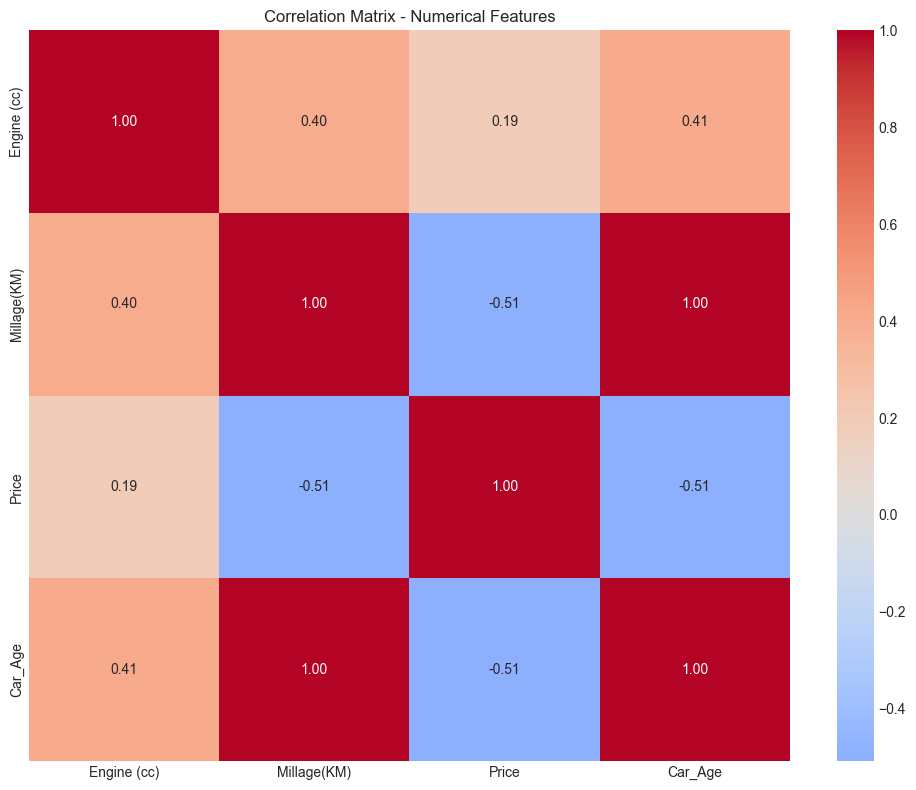


Correlation with Price:
Price          1.000000
Engine (cc)    0.192284
Car_Age       -0.505569
Millage(KM)   -0.507633
Name: Price, dtype: float64


In [31]:
# Correlation heatmap (numerical features only)
numerical_data = data_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
correlation = numerical_data.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with Price:")
print(correlation['Price'].sort_values(ascending=False))

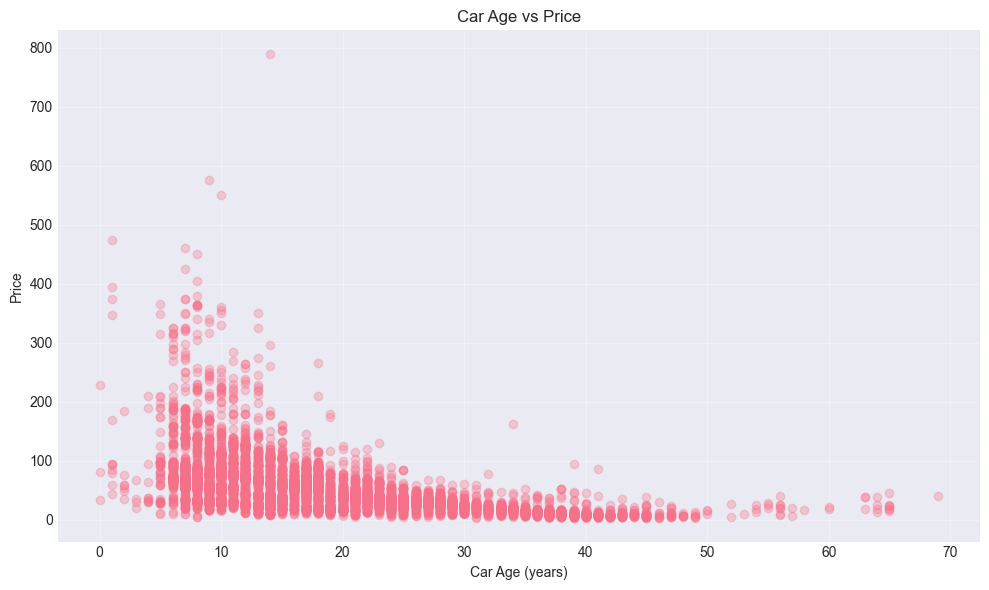

In [32]:
# Car Age vs Price
plt.figure(figsize=(10, 6))
plt.scatter(data_clean['Car_Age'], data_clean['Price'], alpha=0.3)
plt.xlabel('Car Age (years)')
plt.ylabel('Price')
plt.title('Car Age vs Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

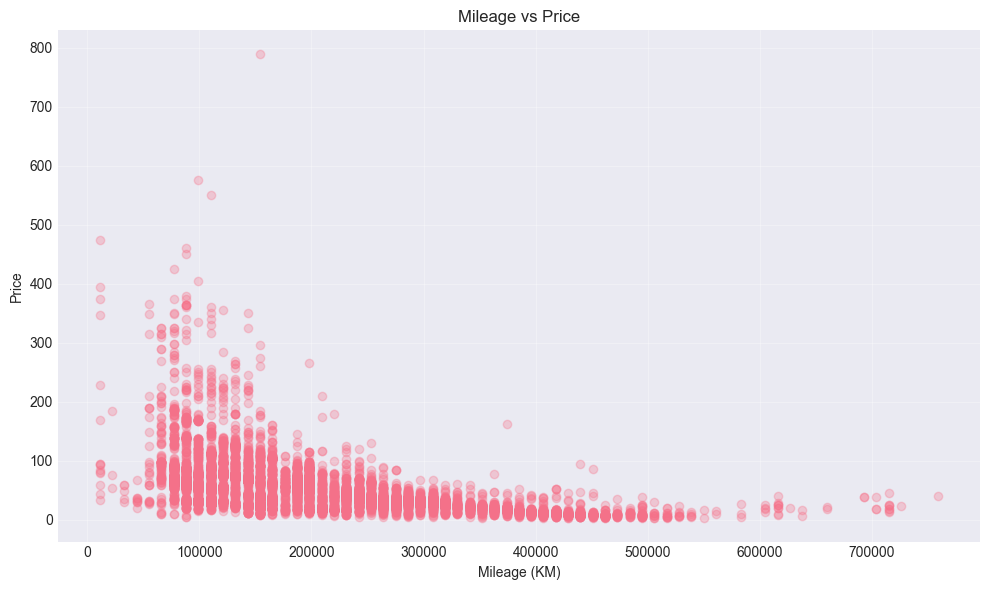

In [33]:
# Mileage vs Price
plt.figure(figsize=(10, 6))
plt.scatter(data_clean['Millage(KM)'], data_clean['Price'], alpha=0.3)
plt.xlabel('Mileage (KM)')
plt.ylabel('Price')
plt.title('Mileage vs Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Summary & Next Steps

### Key Findings from EDA:
- Dataset contains [X] cars with [Y] features
- Price range: [min] to [max]
- Key patterns: [Fill in after running]
- Correlations: [Fill in after running]

### Next Steps - Production Pipeline:

**For model training, use the production scripts:**

```bash
# Step 1: Clean and preprocess data
python preprocess_data.py
# → Creates: car_price_dataset_cleaned.csv

# Step 2: Train optimized XGBoost model
python train_xgboost_advanced.py
# → Advanced features
# → Optuna hyperparameter optimization (100 trials)
# → Fold-wise target encoding
# → Creates: xgboost_car_model_advanced.pkl

# Step 3: Make predictions
python
>>> from preprocessing_utils import preprocess_for_inference
>>> import joblib
>>> artifacts = joblib.load('xgboost_car_model_advanced.pkl')
>>> # ... predict ...
```

**This notebook is for exploration only. Production training is handled by the scripts above.**